## Neural Networks

Every model so far has been a **single neuron** which takes a weighted sum of the inputs, passes it through an activation, and learns the weights with gradient descent. The perceptron drew a straight line, and logistic regression made the output into a probability but kept that line straight. A single neuron can only ever cut the space with one flat boundary.

A **neural network** uses multiple layers of neurons. Each neuron in a layer draws its own line, and the next layer combines those lines, which lets the network make out the curved and complicated boundaries a single neuron never could. To train it we need **backpropagation**, which is just the chain rule worked backward through the layers to find the error signal at each layer. Then it is the same gradient descent we have used all along.

**Forward pass**, for each layer $\ell = 1, \dots, L$:

$$\mathbf{z}^{\ell} = W^{\ell}\mathbf{a}^{\ell-1} + \mathbf{b}^{\ell}, \qquad \mathbf{a}^{\ell} = \sigma(\mathbf{z}^{\ell})$$

**Cost (mean squared error)** over the 10 output neurons:

$$C = \frac{1}{2}\sum_{k=1}^{10}\big(\hat{y}_k - y_k\big)^2$$

**Backpropagation**, the error signal $\delta$ at each layer:

$$\delta^{L} = (\mathbf{a}^{L} - \mathbf{y})\odot\sigma'(\mathbf{z}^{L}), \qquad \delta^{\ell} = \big((W^{\ell+1})^{T}\delta^{\ell+1}\big)\odot\sigma'(\mathbf{z}^{\ell})$$

**Update rule** (gradient descent, error signal $\times$ input):

$$W^{\ell} \leftarrow W^{\ell} - \alpha\,\delta^{\ell}(\mathbf{a}^{\ell-1})^{T}, \qquad \mathbf{b}^{\ell} \leftarrow \mathbf{b}^{\ell} - \alpha\,\delta^{\ell}$$

| Symbol | Meaning |
|--------|---------|
| $\mathbf{x}$ | input image, flattened into a 784-long vector |
| $L$ | number of layers (not counting the input) |
| $W^{\ell}, \mathbf{b}^{\ell}$ | weight matrix and bias vector for layer $\ell$ |
| $\mathbf{z}^{\ell}$ | pre-activation (net input) at layer $\ell$ |
| $\mathbf{a}^{\ell}$ | post-activation output at layer $\ell$, with $\mathbf{a}^{0} = \mathbf{x}$ |
| $\sigma$ | sigmoid activation, applied elementwise |
| $\odot$ | elementwise (Hadamard) multiplication — multiply each pair of matching entries |
| $\hat{y}$ | network output, a vector of 10 scores |
| $\mathbf{y}$ | true label, one-hot encoded |
| $\delta^{\ell}$ | the error signal at layer $\ell$ |
| $\alpha$ | learning rate |

**This notebook** builds a multilayer network in NumPy and trains it to recognize handwritten digits ([MNIST](https://en.wikipedia.org/wiki/MNIST_database)), then runs the same network on clothing images ([Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist)) to see if it works on a harder problem.

## Imports and Setup

We load the data with `tensorflow.keras` if it is available. If not, we fall back to downloading the raw files directly: a GitHub mirror of Yann LeCun's MNIST dataset for MNIST, and Zalando's GitHub for Fashion-MNIST.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_theme()
PURPLE, GREEN = "#5d32ca", "#82b600"

def load_data(fashion=False):
    """Load MNIST or Fashion-MNIST. Use keras if it works; otherwise download from a mirror."""
    # Try keras first (works if TensorFlow is installed and can reach its data).
    try:
        from tensorflow.keras.datasets import mnist, fashion_mnist
        dataset = fashion_mnist if fashion else mnist
        (train_images, train_labels), (test_images, test_labels) = dataset.load_data()
        return train_images, train_labels, test_images, test_labels
    except Exception:
        pass  # any failure at all -> fall back to the mirror below

    import urllib.request, gzip, struct
    base = ("https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/"
            if fashion else "https://raw.githubusercontent.com/fgnt/mnist/master/")
    def grab(name):
        raw = gzip.decompress(urllib.request.urlopen(base + name, timeout=60).read())
        if "images" in name:
            _, n, r, c = struct.unpack(">IIII", raw[:16])
            return np.frombuffer(raw[16:], np.uint8).reshape(n, r, c)
        _, n = struct.unpack(">II", raw[:8])
        return np.frombuffer(raw[8:], np.uint8)
    return (grab("train-images-idx3-ubyte.gz"), grab("train-labels-idx1-ubyte.gz"),
            grab("t10k-images-idx3-ubyte.gz"),  grab("t10k-labels-idx1-ubyte.gz"))

## The Data

MNIST is 70,000 images of handwritten digits, split into 60,000 for training and 10,000 for testing. Each image is a $28 \times 28$ grid of grayscale pixels, labeled with the digit it shows (0 through 9).

train images: (60000, 28, 28)   train labels: (60000,)
test images:  (10000, 28, 28)   test labels:  (10000,)


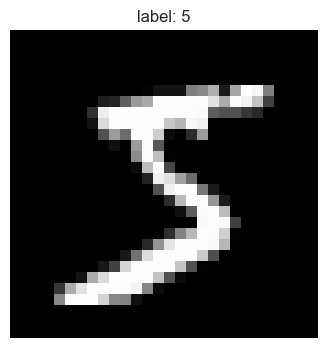

In [3]:
train_X, train_y, test_X, test_y = load_data()
print(f"train images: {train_X.shape}   train labels: {train_y.shape}")
print(f"test images:  {test_X.shape}   test labels:  {test_y.shape}")

# Show one example image and its label.
plt.figure(figsize=(4, 4))
plt.imshow(train_X[0], cmap="gray")
plt.title(f"label: {train_y[0]}")
plt.axis("off")
plt.show()

### Preprocessing

Three steps prepare the images for the network:

- **Scale** the pixel values from 0–255 down to 0–1, so the sigmoid inputs stay in a sensible range (the same scaling idea from the earlier notebooks).
- **Flatten** each $28 \times 28$ image into a single column vector of length $784 = 28 \times 28$, since the network takes a flat vector of features.
- **One-hot encode** each label into a length-10 vector, for example the digit 3 becomes a vector with a 1 in position 3 and 0s elsewhere, matching the 10 output neurons.

In [4]:
def preprocess(images, labels):
    # (N, 28, 28) -> (784, N): each image becomes a column, scaled to [0, 1].
    X = (images.reshape(images.shape[0], -1) / 255.0).T
    # labels -> (10, N) one-hot: column i has a 1 in the row of its digit.
    Y = np.zeros((10, labels.size))
    Y[labels, np.arange(labels.size)] = 1.0
    return X, Y

X_train, Y_train = preprocess(train_X, train_y)
X_test,  Y_test  = preprocess(test_X,  test_y)
print(f"X_train: {X_train.shape}   Y_train: {Y_train.shape}")

X_train: (784, 60000)   Y_train: (10, 60000)


## How the Network Learns

The whole process is three steps repeated many times.

**Forward pass.** An image enters as $\mathbf{a}^0 = \mathbf{x}$ and flows through the layers. Each layer computes a net input $\mathbf{z}^{\ell} = W^{\ell}\mathbf{a}^{\ell-1} + \mathbf{b}^{\ell}$ and passes it through the sigmoid to get $\mathbf{a}^{\ell} = \sigma(\mathbf{z}^{\ell})$. The last layer's 10 outputs are the network's scores for each digit.

**Cost.** We measure how wrong the output is with mean squared error against the one-hot label, $C = \tfrac{1}{2}\sum_k(\hat{y}_k - y_k)^2$.

**Backward pass.** To improve, we need each weight's gradient. Backpropagation gets it by computing an error signal $\delta$ for each layer, starting at the output and moving back. The output error signal is $\delta^{L} = (\mathbf{a}^{L} - \mathbf{y})\odot\sigma'(\mathbf{z}^{L})$, and each hidden layer's error signal is the next layer's error signal carried back through its weights, $\delta^{\ell} = \big((W^{\ell+1})^{T}\delta^{\ell+1}\big)\odot\sigma'(\mathbf{z}^{\ell})$. Each weight's gradient is then its neuron's error signal times the input that fed it, and we step downhill: $W^{\ell} \leftarrow W^{\ell} - \alpha\,\delta^{\ell}(\mathbf{a}^{\ell-1})^{T}$.

First the sigmoid and its derivative, which appear in both the forward and backward passes.

In [5]:
def sigmoid(z):
    # Clamp z to [-500, 500] so np.exp never overflows, early in training, weights
    # can produce extreme values, and sigmoid(-500) ≈ 0 anyway so nothing is lost.
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def d_sigmoid(z):
    # Derivative of the sigmoid: sigma'(z) = sigma(z) * (1 - sigma(z)).
    s = sigmoid(z)
    return s * (1.0 - s)

### The `DenseNetwork` Class

The architecture is just a list of layer sizes, for example `[784, 128, 64, 10]` for 784 inputs, two hidden layers, and 10 outputs. The weights and biases are stored as lists indexed by layer.

One practical change from training one image at a time: we push a whole **batch** of images through at once as a matrix (each image is a column). The math is identical to the per-image version, it is just done in bulk, which is far faster and is exactly what deep learning libraries do under the hood. We average the gradient over the batch before each step (mini-batch stochastic gradient descent).

**Weight initialization.** Before training starts, the weights are set to small random values. This matters more than it sounds: on the very first forward pass, the signal travels through every layer multiplied by those random weights. If the weights are too large the values explode by the final layer; if they are too small they vanish to near zero. Either way the first error signal is usually bad garbage and training starts off broken. **Xavier initialization** (`scale = sqrt(1 / fan_in)`) is designed specifically for sigmoid activations, it picks a scale that keeps the signal stable across layers, so the first pass produces meaningful numbers and training can begin cleanly.

In [6]:
class DenseNetwork:
    """A fully connected feedforward neural network trained with mini-batch SGD and backprop.

    Parameters
    ----------
    layers : list of int
        Sizes of each layer, e.g. [784, 128, 64, 10] (input, hidden..., output).

    Attributes
    ----------
    W, B : list of np.ndarray
        Weight matrices and bias vectors, indexed by layer (index 0 is unused).
    errors_ : list of float
        Mean squared error over the training set after each epoch.
    """

    def __init__(self, layers=[784, 128, 64, 10]):
        self.layers = layers
        self.W = [None]   # index 0 unused so layer L lines up with W[L]
        self.B = [None]
        for i in range(1, len(layers)):
            # Xavier initialization: scale by sqrt(1 / fan_in), suited for sigmoid activations.
            self.W.append(np.random.randn(layers[i], layers[i-1]) * np.sqrt(1.0 / layers[i-1]))
            self.B.append(np.zeros((layers[i], 1)))

    def forward(self, A0):
        """Run a batch of inputs (shape (784, batch)) forward, returning all z and a values."""
        Z, A = [None], [A0]
        for i in range(1, len(self.layers)):
            z = self.W[i] @ A[i-1] + self.B[i]   # net input  z = W a + b
            Z.append(z)
            A.append(sigmoid(z))                 # activation  a = sigma(z)
        return Z, A

    def train(self, X, Y, alpha=1.5, epochs=25, batch_size=64):
        """Learn the weights with backprop and mini-batch stochastic gradient descent."""
        L = len(self.layers) - 1
        N = X.shape[1]
        self.errors_ = []

        for epoch in range(epochs):
            order = np.random.permutation(N)        # shuffle so the network doesn't learn the order
            for start in range(0, N, batch_size):
                idx = order[start:start + batch_size]
                A0, Yb = X[:, idx], Y[:, idx]      # pull out this batch of images and labels
                m = A0.shape[1]                     # number of images in this batch
                Z, A = self.forward(A0)             # forward pass: get activations at every layer

                # Output error signal: (prediction - target) * sigmoid'(z).
                deltas = {L: (A[L] - Yb) * d_sigmoid(Z[L])}
                # Hidden error signal: carry the next layer's error signal back through its weights.
                for i in range(L - 1, 0, -1):
                    deltas[i] = (self.W[i+1].T @ deltas[i+1]) * d_sigmoid(Z[i])
                # Update: each weight steps down by (error signal x input), averaged over the batch.
                for i in range(1, L + 1):
                    self.W[i] -= alpha * (deltas[i] @ A[i-1].T) / m
                    self.B[i] -= alpha * deltas[i].mean(axis=1, keepdims=True)

            # Record the MSE over the whole training set for this epoch.
            _, A = self.forward(X)
            self.errors_.append(0.5 * np.mean(np.sum((A[L] - Y) ** 2, axis=0)))
            print(f"epoch {epoch + 1:2d}/{epochs}  MSE = {self.errors_[-1]:.4f}")
        return self

    def predict(self, X):
        """Return the predicted digit for each input: the output neuron with the highest score."""
        _, A = self.forward(X)
        return np.argmax(A[-1], axis=0)

## Training on MNIST

We build a network with two hidden layers, `[784, 128, 64, 10]`, and train it. The MSE should fall steadily as the network learns to map images to the right digit.

In [7]:
net = DenseNetwork(layers=[784, 128, 64, 10])
net.train(X_train, Y_train, alpha=1., epochs=25, batch_size=64)

epoch  1/25  MSE = 0.1448
epoch  2/25  MSE = 0.0834
epoch  3/25  MSE = 0.0687
epoch  4/25  MSE = 0.0598
epoch  5/25  MSE = 0.0532
epoch  6/25  MSE = 0.0488
epoch  7/25  MSE = 0.0444
epoch  8/25  MSE = 0.0406
epoch  9/25  MSE = 0.0375
epoch 10/25  MSE = 0.0357
epoch 11/25  MSE = 0.0335
epoch 12/25  MSE = 0.0316
epoch 13/25  MSE = 0.0307
epoch 14/25  MSE = 0.0277
epoch 15/25  MSE = 0.0275
epoch 16/25  MSE = 0.0252
epoch 17/25  MSE = 0.0233
epoch 18/25  MSE = 0.0228
epoch 19/25  MSE = 0.0216
epoch 20/25  MSE = 0.0205
epoch 21/25  MSE = 0.0194
epoch 22/25  MSE = 0.0190
epoch 23/25  MSE = 0.0186
epoch 24/25  MSE = 0.0172
epoch 25/25  MSE = 0.0166


### The Cost Over Training

The error drops quickly at first as the network learns the obvious patterns, then flattens as it fine-tunes the harder, messier digits.

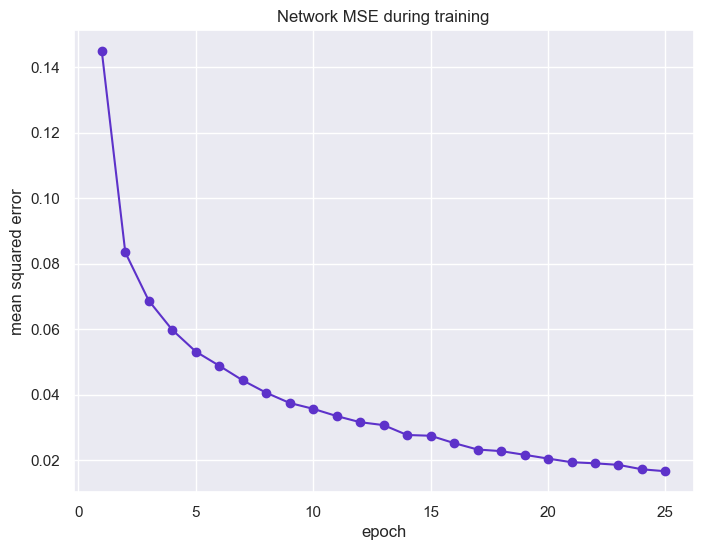

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(net.errors_) + 1), net.errors_, marker="o", color=PURPLE)
plt.xlabel("epoch")
plt.ylabel("mean squared error")
plt.title("Network MSE during training")
plt.show()

## Evaluating

We check accuracy on the 10,000 test images the network never trained on, then look at the **confusion matrix**, a 10x10 grid showing which digits get predicted as which. A clean diagonal means most predictions are correct; the off-diagonal cells reveal the mix-ups (the common ones are 4 vs 9 and 3 vs 5).

Test accuracy: 97.21%


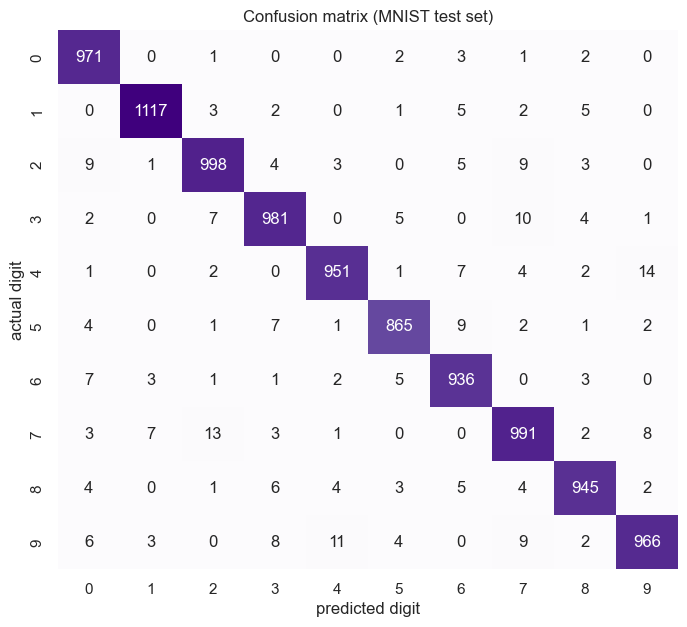

In [9]:
pred_test = net.predict(X_test)
accuracy = (pred_test == test_y).mean()
print(f"Test accuracy: {accuracy:.2%}")

cm = confusion_matrix(test_y, pred_test)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.xlabel("predicted digit")
plt.ylabel("actual digit")
plt.title("Confusion matrix (MNIST test set)")
plt.show()

### Looking at Predictions

A handful of random test images with the network's guess. Green titles are correct, red are misses, which usually turn out to be genuinely sloppy or ambiguous handwriting.

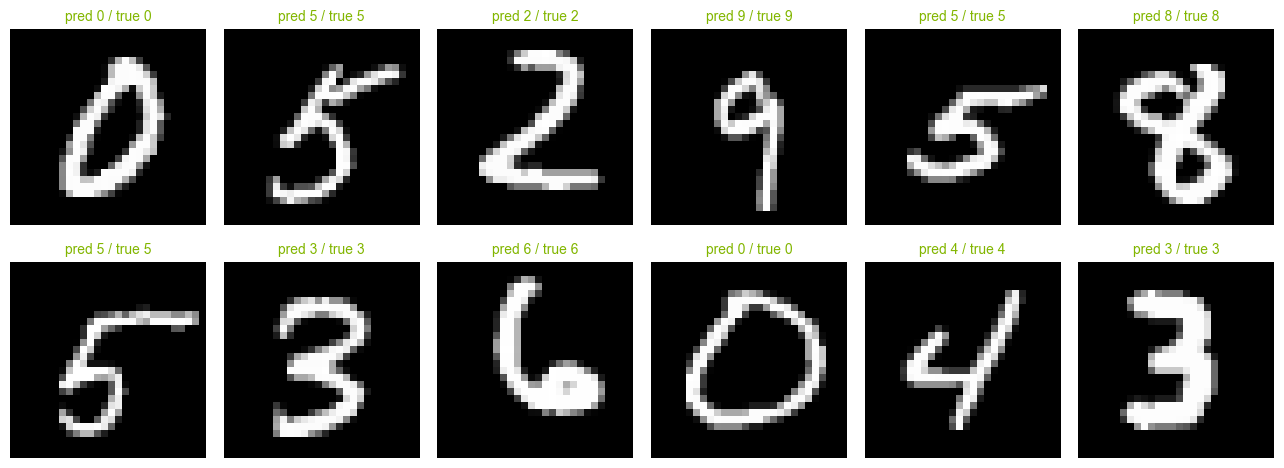

In [10]:
fig, axes = plt.subplots(2, 6, figsize=(13, 5))
for ax in axes.ravel():
    i = np.random.randint(len(test_y))
    guess = net.predict(X_test[:, i:i+1])[0]
    ax.imshow(test_X[i], cmap="gray")
    ax.set_title(f"pred {guess} / true {test_y[i]}",
                 color=(GREEN if guess == test_y[i] else "#c0392b"), fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Try It Yourself

Draw a digit on the black canvas below and click **Predict**. The network classifies it exactly the same way it classifies MNIST test images: your drawing is cropped to its bounding box, centered, scaled down to $28 \times 28$ pixels, and fed pixel-by-pixel into the network as a flat 784-long vector.

After you click Predict you will see two panels. The left panel shows the $28 \times 28$ image the network actually received — this is the most useful thing to check when it gets something wrong, because what looks clear at full size can look very different at 28 pixels. The right panel shows the output score for each digit, so you can tell whether the network was confident or just barely picked one over another.

A few things that help:
- Draw **big and centered** — the preprocessing crops to the bounding box, so a small drawing in the corner gets stretched in unexpected ways
- Draw **slowly and deliberately** — fast mouse moves can leave gaps in the stroke
- For digits with horizontal bars (like 7), make the bar **wide and clear**, it shrinks significantly in the downscale and can disappear if it was faint

The cell below installs `ipycanvas` automatically if needed, just run both cells in order.

In [20]:
try:
    import ipycanvas
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "ipycanvas"], check=True)

In [ ]:
from ipycanvas import Canvas
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import io

SCALE = 10  # canvas is 280×280 pixels — 10× the 28×28 network input so it's easy to draw on

# sync_image_data=True keeps the canvas pixel data continuously available in Python
# so canvas.image_data gives us the current drawing as PNG bytes the moment we ask for it
canvas = Canvas(width=28 * SCALE, height=28 * SCALE, sync_image_data=True)
canvas.fill_style = 'black'
canvas.fill_rect(0, 0, 28 * SCALE, 28 * SCALE)  # start with a black background

drawing = [False]  # list instead of a bool so the nested functions can mutate it

def start_draw(x, y):
    drawing[0] = True
    canvas.begin_path()   # start a fresh path at the click point
    canvas.move_to(x, y)

def do_draw(x, y):
    if not drawing[0]:
        return            # mouse is moving but button isn't held — ignore
    canvas.stroke_style = 'white'
    canvas.line_width = 20   # 20px on a 280px canvas → ~2px after downscale to 28×28
    canvas.line_cap = 'round'  # rounded ends prevent spiky gaps between line segments
    canvas.line_to(x, y)  # extend the path to the current mouse position
    canvas.stroke()
    canvas.begin_path()   # reset so each segment is drawn immediately, not accumulated
    canvas.move_to(x, y)

def stop_draw(x, y):
    drawing[0] = False    # mouse released — stop drawing

canvas.on_mouse_down(start_draw)
canvas.on_mouse_move(do_draw)
canvas.on_mouse_up(stop_draw)

output = widgets.Output()  # placeholder widget where prediction results will be shown

def center_and_resize(gray):
    """Crop to the digit's bounding box, center it, then resize to 28×28.

    MNIST digits are always centered in a 28×28 frame with a small border.
    If we skip this step, a digit drawn in the corner looks completely different
    to the network from what it was trained on, which is the main cause of wrong predictions.
    """
    # Find which rows and columns contain any drawn pixel (above noise threshold of 10)
    rows = np.any(gray > 10, axis=1)
    cols = np.any(gray > 10, axis=0)
    if not rows.any():
        return np.zeros((28, 28), dtype=np.uint8)  # nothing was drawn
    # Tight bounding box around the drawn pixels
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = gray[rmin:rmax+1, cmin:cmax+1]
    # Embed the cropped digit into a square canvas so resizing doesn't stretch it
    h, w = cropped.shape
    size = max(h, w)
    square = np.zeros((size, size), dtype=np.uint8)
    square[(size - h) // 2:(size - h) // 2 + h,
           (size - w) // 2:(size - w) // 2 + w] = cropped
    # Add padding around the digit to match the MNIST margin (about 25% on each side)
    border = size // 4
    padded = np.pad(square, border, constant_values=0)
    # Downsample to 28×28 using Lanczos filtering to preserve edge detail
    return np.array(Image.fromarray(padded).resize((28, 28), Image.LANCZOS))

def on_predict(b):
    # Read the canvas as PNG bytes and convert to a grayscale numpy array
    img = Image.open(io.BytesIO(canvas.image_data)).convert('L')
    gray = np.array(img)
    # Preprocess the same way MNIST images are: center, crop, resize to 28×28
    processed = center_and_resize(gray)
    # Flatten to a 784-element column vector and scale pixels from 0–255 to 0–1
    X = (processed.flatten() / 255.0).reshape(784, 1)
    pred = net.predict(X)[0]
    # Run the forward pass again to get the raw output score for each digit
    _, A = net.forward(X)
    scores = A[-1].flatten()
    with output:
        output.clear_output()
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        # Left panel: show the 28×28 image the network actually received
        # This is the most useful diagnostic — if your 7 looks like a 1 here, the network
        # is not wrong; it's seeing something that genuinely resembles a 1
        axes[0].imshow(processed, cmap='gray')
        axes[0].set_title(f"What the network sees  →  pred: {pred}", fontsize=11)
        axes[0].axis('off')
        # Right panel: output score for every digit — a close bar chart means low confidence
        colors = [GREEN if i == pred else PURPLE for i in range(10)]
        axes[1].bar(range(10), scores, color=colors)
        axes[1].set_xticks(range(10))
        axes[1].set_xlabel('digit')
        axes[1].set_ylabel('output score')
        axes[1].set_title('Confidence per digit', fontsize=11)
        plt.tight_layout()
        plt.show()

def on_clear(b):
    output.clear_output()
    canvas.fill_style = 'black'
    canvas.fill_rect(0, 0, 28 * SCALE, 28 * SCALE)  # reset canvas to black

predict_btn = widgets.Button(description='Predict', button_style='primary')
clear_btn = widgets.Button(description='Clear')
predict_btn.on_click(on_predict)
clear_btn.on_click(on_clear)

display(canvas, widgets.HBox([predict_btn, clear_btn]), output)

Canvas(height=280, sync_image_data=True, width=280)

Output()

## Does It Generalize? Fashion-MNIST

Fashion-MNIST is a drop-in replacement: the same 70,000 images at $28 \times 28$ with 10 classes, but the classes are clothing items instead of digits, and they are much harder to tell apart (a pullover, a coat, and a shirt look very similar in 28 pixels). We run the **exact same network and code**, only the data changes.

In [15]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Load and preprocess Fashion-MNIST, same pipeline as MNIST, only the data changes
f_train_X, f_train_y, f_test_X, f_test_y = load_data(fashion=True)
fX_train, fY_train = preprocess(f_train_X, f_train_y)
fX_test,  fY_test  = preprocess(f_test_X,  f_test_y)

# Train the exact same network architecture, nothing changed except the data going in
fashion_net = DenseNetwork(layers=[784, 128, 64, 10])
fashion_net.train(fX_train, fY_train, alpha=1.5, epochs=25, batch_size=64)

epoch  1/25  MSE = 0.1589
epoch  2/25  MSE = 0.1358
epoch  3/25  MSE = 0.1211
epoch  4/25  MSE = 0.1163
epoch  5/25  MSE = 0.1102
epoch  6/25  MSE = 0.1017
epoch  7/25  MSE = 0.1019
epoch  8/25  MSE = 0.1120
epoch  9/25  MSE = 0.0898
epoch 10/25  MSE = 0.0964
epoch 11/25  MSE = 0.0856
epoch 12/25  MSE = 0.0882
epoch 13/25  MSE = 0.0870
epoch 14/25  MSE = 0.0840
epoch 15/25  MSE = 0.0802
epoch 16/25  MSE = 0.0755
epoch 17/25  MSE = 0.0754
epoch 18/25  MSE = 0.0841
epoch 19/25  MSE = 0.0826
epoch 20/25  MSE = 0.0758
epoch 21/25  MSE = 0.0716
epoch 22/25  MSE = 0.0697
epoch 23/25  MSE = 0.0776
epoch 24/25  MSE = 0.0713
epoch 25/25  MSE = 0.0677


### The Cost Over Training

The error drops more slowly than on MNIST and doesn't get nearly as low, clothing categories are just harder to separate than handwritten digits.

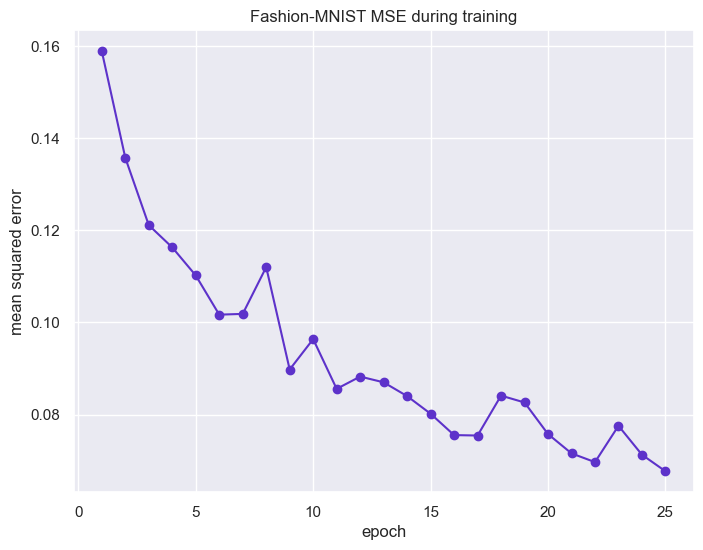

In [16]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(fashion_net.errors_) + 1), fashion_net.errors_, marker="o", color=PURPLE)
plt.xlabel("epoch")
plt.ylabel("mean squared error")
plt.title("Fashion-MNIST MSE during training")
plt.show()

### Testing on Data the Network Has Never Seen

The test set that the network has never seen these 10,000 images during training. The accuracy here is what actually matters: it tells us how well the network generalises to new clothing images, not just the ones it trained on.

In [17]:
# Run predictions on the 10,000 test images the network has never seen
f_pred = fashion_net.predict(fX_test)
print(f"Fashion-MNIST test accuracy: {(f_pred == f_test_y).mean():.2%}")

Fashion-MNIST test accuracy: 87.81%


### Fashion-MNIST Predictions

The same view, now with clothing. The lower accuracy is expected, the network is unchanged, but the problem is genuinely harder.

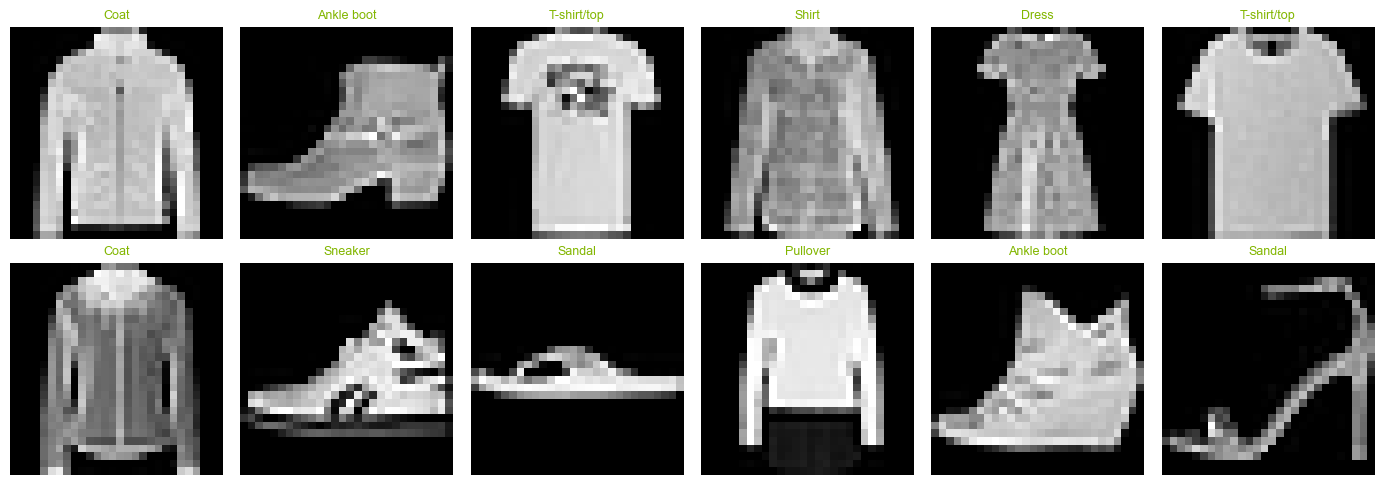

In [18]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax in axes.ravel():
    i = np.random.randint(len(f_test_y))
    guess = fashion_net.predict(fX_test[:, i:i+1])[0]
    ax.imshow(f_test_X[i], cmap="gray")
    ok = guess == f_test_y[i]
    ax.set_title(f"{CLASS_NAMES[guess]}", color=(GREEN if ok else "#c0392b"), fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Conclusion

Stacking neurons into layers and training them with backpropagation turned the same basic unit from the very first notebook into a model that recognizes handwritten digits with around 97–98% accuracy. Nothing about the core idea changed: each neuron still computes $\sigma(\mathbf{w}\cdot\mathbf{x} + b)$, and we still learn by gradient descent. The two additions were **depth**, which gives the network the curved decision boundaries a single neuron could never draw, and **backpropagation**, which is just the chain rule run backward to find the error signal at each layer. Each weight then steps downhill by its layer's error signal times the input that fed it.

Running the identical network on Fashion-MNIST shows both its reach and its limits: it still learns clothing reasonably well, but the lower accuracy reflects a genuinely harder problem where a fully connected network starts to hit a ceiling. That ceiling is what motivates the models that are different from this one, such as convolutional networks built specifically for images. From a single straight line in the perceptron notebook to a digit classifier here, every model in this repository has been the same machine: a weighted sum, an activation, and gradient descent, scaled up.